# Non-pharmaceutical intervention control

**Reza Sameni**  
Emory University

SI-alpha model fitting, scenario forecasts, and bounded intervention policies.

## Topics

- Fit the two-pass SI-alpha/NNLS pipeline.
- Forecast under known policies.
- Inspect bounded finite-horizon intervention control.

**Run:** install the package with `python -m pip install -e ".[notebooks,dev]"`, then run all cells in order. All numerical functions are imported from `src/epidemic_modeling`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML
import epidemic_modeling as em
from epidemic_modeling.plotting import (
    configure_plots,
    repository_root,
    plot_compartments,
    plot_growth,
)

root = repository_root()
configure_plots()
print(f"epidemic_modeling {em.__version__} · local data")


epidemic_modeling 2.0.0 · local data


## A transparent synthetic training example

The contact rate obeys $\dot\alpha=\gamma[b+\mathbf a^\mathsf T(\mathbf u_{\max}-\mathbf u)-\alpha]$.
We first estimate it from cases, then fit nonnegative intervention effects. These effects summarize a model fit; correlated policies and reporting artifacts limit causal interpretation.

The upgraded training workflow uses deterministic cyclic-coordinate NNLS in both languages. All computation is in imported functions.

,First-pass effect,Refined effect
Intervention 1,0.017861,0.039552
Intervention 2,0.056723,0.080228


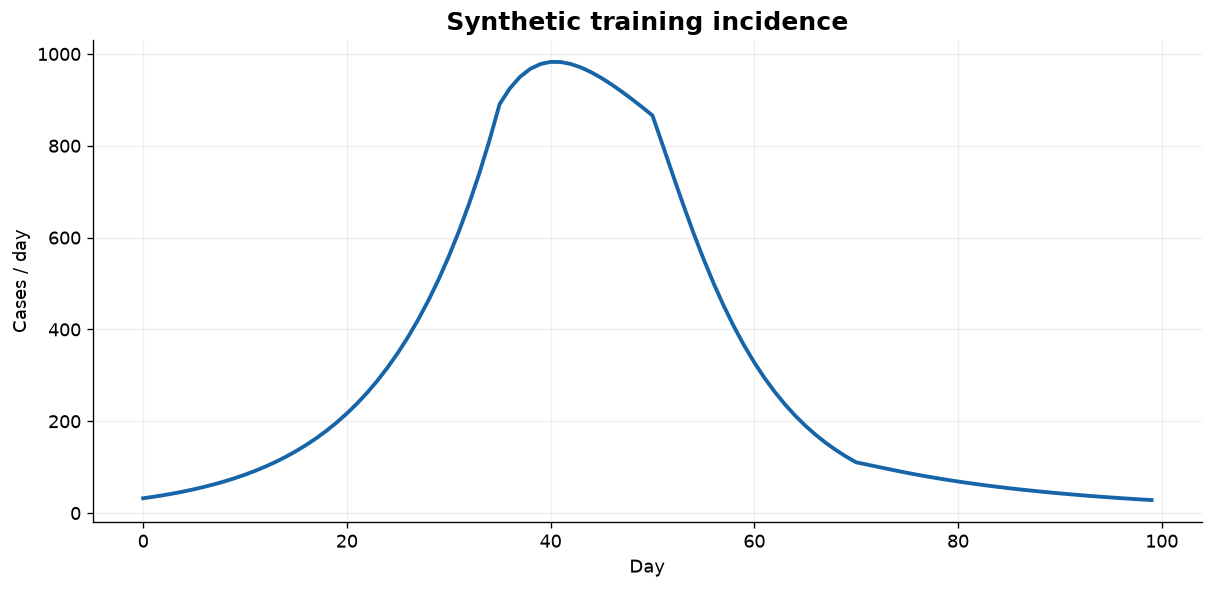

In [2]:
population = 1_000_000
day = np.arange(100)
u = np.vstack(
    [np.where(day < 35, 0, np.where(day < 70, 2, 1)), np.where(day < 50, 0, 2)]
)
true_model = {
    "population": population,
    "params": em.default_si_params([3, 3]),
    "state": [0.9999, 0.0001, 0.32],
    "covariance": np.diag([1e-8, 1e-8, 0.01]).tolist(),
}
true_model["params"].update(a=np.array([0.06, 0.04]), b=0.02)
new_cases, _ = em.forecast_npi(true_model, u)
cumulative = np.cumsum(new_cases)
model = em.fit_npi_model(cumulative, u, population, [3, 3])
display(
    pd.DataFrame(
        {
            "First-pass effect": model["coefficients"],
            "Refined effect": model["refined_coefficients"],
        },
        index=["Intervention 1", "Intervention 2"],
    )
)
fig, ax = plt.subplots()
ax.plot(day, new_cases)
ax.set(title="Synthetic training incidence", xlabel="Day", ylabel="Cases / day")
plt.show()


## Fixed policy versus costate-based control

For each missing control, the switching function is $\phi_j=\epsilon w_j-\gamma\lambda_\alpha a_j$.
The six-state model includes three costates and applies lower or upper intervention bounds according to the sign of $\phi$. Zero terminal costates are enforced by repeated EKF/EKS shooting. This solver has a finite iteration cap and does not assert global optimality.

The control objective uses population fractions, while the reported human-cost table shows cases/day. Intervention weights are order one, so small `epsilon` values illustrate the switching regime. The finite-iteration solver may produce non-monotonic tradeoffs; inspect convergence rather than assuming the table is a certified Pareto frontier.

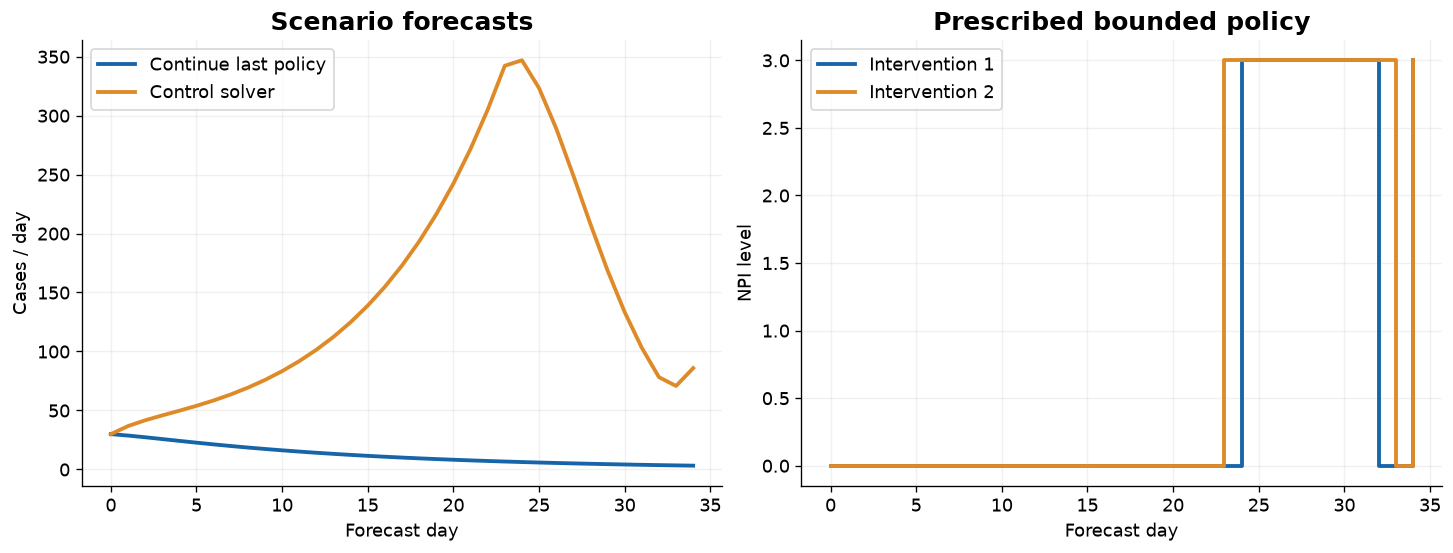

In [3]:
horizon = 35
weights = np.array([1.0, 1.5])
fixed = np.repeat(u[:, -1, None], horizon, axis=1)
fixed_cases, _ = em.forecast_npi(model, fixed)
controls, controlled_cases, controlled_states = em.optimal_npi(
    model, horizon, weights, epsilon=3e-5
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fixed_cases, label="Continue last policy")
axes[0].plot(controlled_cases, label="Control solver")
axes[0].set(title="Scenario forecasts", xlabel="Forecast day", ylabel="Cases / day")
axes[0].legend()
for j in range(len(weights)):
    axes[1].step(
        np.arange(horizon), controls[j], where="post", label=f"Intervention {j+1}"
    )
axes[1].set(
    title="Prescribed bounded policy", xlabel="Forecast day", ylabel="NPI level"
)
axes[1].legend()
plt.show()
assert np.all((controls >= 0) & (controls <= 3))


In [4]:
tradeoffs = []
for epsilon in [0, 1e-6, 1e-5, 3e-5, 1e-4, 1e-3]:
    policy, predicted, _ = em.optimal_npi(model, horizon, weights, epsilon)
    human, npi = em.npi_cost(predicted, policy, weights)
    tradeoffs.append(
        {"epsilon": epsilon, "mean_cases": human, "mean_weighted_npi": npi}
    )
display(pd.DataFrame(tradeoffs).round(3))


,epsilon,mean_cases,mean_weighted_npi
0,0.000,137.625,1.071
1,0.000,103.075,1.564
2,0.000,115.709,1.457
3,0.000,146.654,1.093
4,0.000,143.223,0.836
5,0.001,319.456,0.000


## Historical paper figure

The existing US figure below illustrates the original research's bi-objective experiments, trained on historical policies and forecast over 120 days. The synthetic example above is smaller and synthetic; it is not a reproduction of that country experiment.

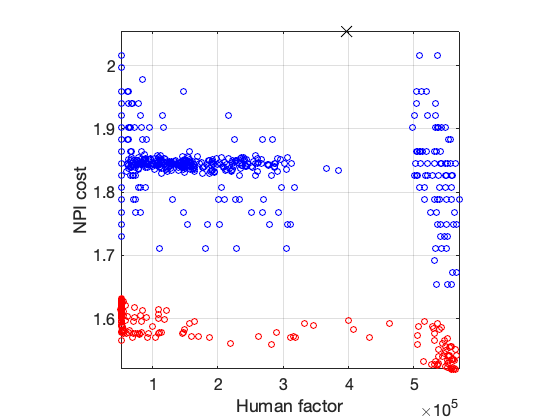

In [5]:
display(Image(filename=str(root / "figures/US.png"), width=650))


## Further experiments

- Increase the cost of the second intervention and inspect the prescribed policy.
- Compare the synthetic generating effects with fitted effects; explain identifiability.
- Check whether the shooting solution stabilizes as the iteration cap increases.

**Paired MATLAB example:** `demo_intervention_control`.

## References and next steps

1. Reza Sameni (2020). *Mathematical Modeling of Epidemic Diseases; A Case Study of the COVID-19 Coronavirus*. [arXiv:2003.11371](https://arxiv.org/abs/2003.11371).
2. Reza Sameni (2022). *Model-Based Prediction and Optimal Control of Pandemics by Non-Pharmaceutical Interventions*. IEEE JSTSP, **16**(2), 307–317. [DOI:10.1109/JSTSP.2021.3129118](https://doi.org/10.1109/JSTSP.2021.3129118).

Equations and existing research images originate from the cited work and the [original repository](https://github.com/alphanumericslab/EpidemicModeling). Consult `docs/api.md` for array shapes and `docs/migration.md` for deliberate fixes.